In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:

# 1. Load Data
print("1. Loading Data...")
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("First 5 rows of features:\n", X.head())
print("Target value counts:\n", y.value_counts())



1. Loading Data...
Dataset loaded successfully.
Features (X) shape: (569, 30)
Target (y) shape: (569,)
First 5 rows of features:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980   

In [4]:
# 2. Data Cleanup (Check for missing values and scale data)
print("\n2. Data Cleanup...")
print("Missing values per column:\n", X.isnull().sum())

# For this dataset, there are no missing values, so we'll proceed with scaling.

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Data scaled successfully. First 5 rows of scaled data:\n", X_scaled_df.head())





2. Data Cleanup...
Missing values per column:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
Data scaled successfully. First 5 rows of scaled data:
    mean radiu


3. Performing EDA...


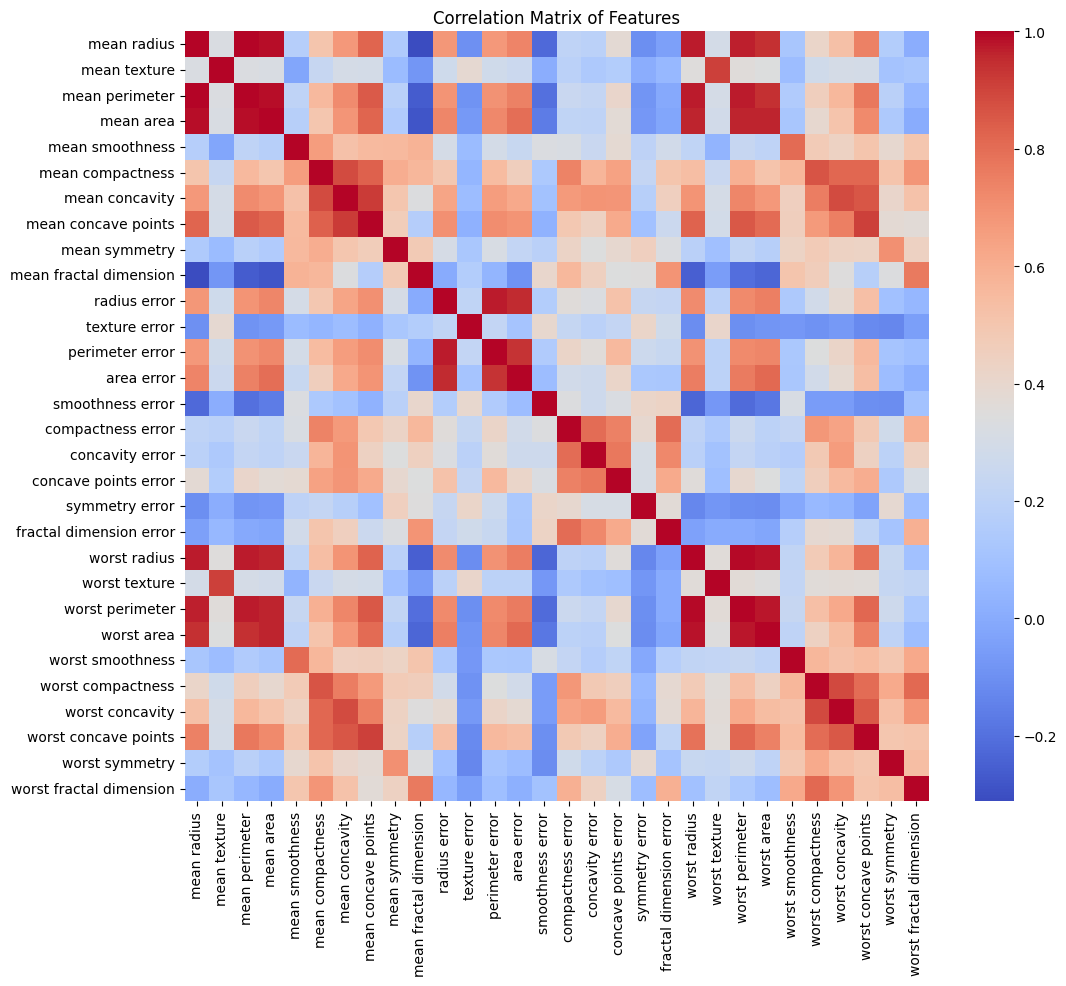

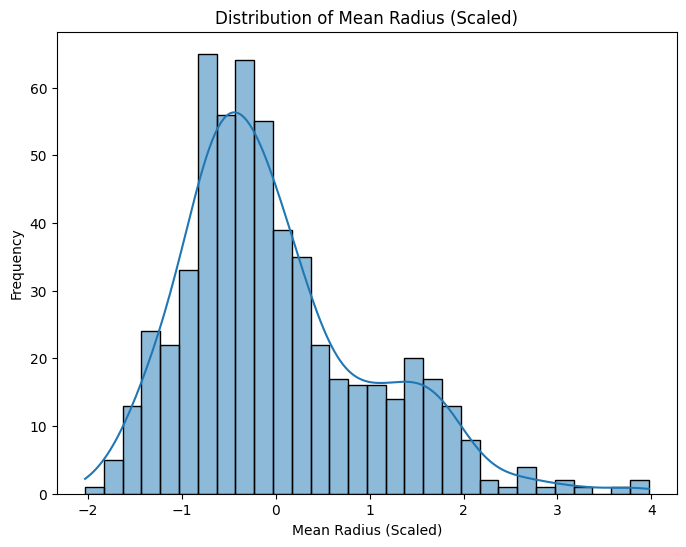

In [5]:
# 3. Exploratory Data Analysis (EDA)
print("\n3. Performing EDA...")

# Pairplot for a subset of features (can be very slow for many features)
# plt.figure(figsize=(12, 10))
# sns.pairplot(X_scaled_df.iloc[:, :5].assign(target=y), hue='target')
# plt.suptitle('Pairplot of first 5 features by Target', y=1.02)
# plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

# Distribution of a sample feature
plt.figure(figsize=(8, 6))
sns.histplot(X_scaled_df['mean radius'], kde=True, bins=30)
plt.title('Distribution of Mean Radius (Scaled)')
plt.xlabel('Mean Radius (Scaled)')
plt.ylabel('Frequency')
plt.show()




In [6]:
# 4. Train and Test Split
print("\n4. Splitting Data into Training and Test Sets...")
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")





4. Splitting Data into Training and Test Sets...
X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)


In [7]:
# 5. Choosing the Algorithm (Support Vector Classifier)
print("\n5. Initializing the Support Vector Machine (SVC) model...")
# We'll start with a common kernel, 'rbf' (Radial Basis Function)
svm_model = SVC(kernel='rbf', random_state=42)
print("SVC model initialized with RBF kernel.")





5. Initializing the Support Vector Machine (SVC) model...
SVC model initialized with RBF kernel.


In [8]:
# 6. Fit the data to model
print("\n6. Training the SVM model...")
svm_model.fit(X_train, y_train)
print("Model training complete.")





6. Training the SVM model...
Model training complete.



7. Evaluating the model on the test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        64
           1       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


Confusion Matrix:


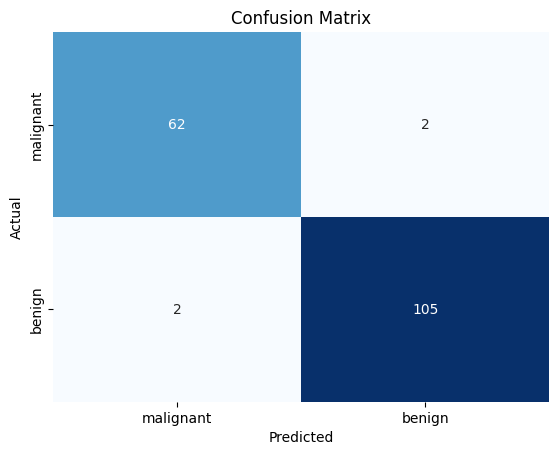

Accuracy on Test Set: 0.9766


In [9]:
# 7. Metrics and Test the Model
print("\n7. Evaluating the model on the test set...")
y_pred = svm_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Test Set: {accuracy:.4f}")




In [ ]:
# 8. Evaluation and Test with external data (simulated)
print("\n8. Testing with simulated 'external' data...")

# Simulate external data by taking a small, unseen portion of the original data
# or by generating new data points (ensure they are scaled correctly).
# For simplicity, we'll take a small subset from the original dataset's unused part.

# Let's assume we want to predict on a few new, unseen samples.
# We'll take a few rows from the original scaled features that were not in train/test.

# Get indices of X_scaled_df not in X_train or X_test
all_indices = X_scaled_df.index
train_test_indices = set(X_train.index).union(set(X_test.index))
external_data_indices = list(set(all_indices) - train_test_indices)

if len(external_data_indices) > 5:
    simulated_external_X = X_scaled_df.loc[external_data_indices[:5]]
    simulated_external_y = y.loc[external_data_indices[:5]]
else:
    print("Not enough remaining data to simulate external data. Using a subset of X_test for demonstration.")
    simulated_external_X = X_test.iloc[:5]
    simulated_external_y = y_test.iloc[:5]

print("Simulated external data (first 5 samples):\n", simulated_external_X.head())




8. Testing with simulated 'external' data...
Not enough remaining data to simulate external data. Using a subset of X_test for demonstration.
Simulated external data (first 5 samples):
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
14     -0.112836      0.772668        0.067180  -0.217827         1.191289   
150    -0.320167      0.346815       -0.348429  -0.385345         1.219756   
275    -0.635423     -0.449042       -0.649530  -0.623681         1.860245   
83      1.412320      1.629029        1.529432   1.356952         1.789079   
86      0.100174      0.505055        0.093953  -0.019024        -0.136658   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
14           2.368158        1.556825             0.808147       0.939685   
150         -0.539188       -0.721149            -0.579569       2.659279   
275         -0.611014       -0.370489             0.647967       0.742534   
83           1.416794        1.31702

In [11]:
# Predict on the simulated external data
external_predictions = svm_model.predict(simulated_external_X)

print("\nPredictions on simulated external data:")
for i, (actual, pred) in enumerate(zip(simulated_external_y, external_predictions)):
    print(f"Sample {i+1}: Actual='{data.target_names[actual]}' vs. Predicted='{data.target_names[pred]}' (Match: {actual == pred})")

print("\nProcess complete.")


Predictions on simulated external data:
Sample 1: Actual='malignant' vs. Predicted='malignant' (Match: True)
Sample 2: Actual='benign' vs. Predicted='benign' (Match: True)
Sample 3: Actual='benign' vs. Predicted='benign' (Match: True)
Sample 4: Actual='malignant' vs. Predicted='malignant' (Match: True)
Sample 5: Actual='malignant' vs. Predicted='malignant' (Match: True)

Process complete.
